<a href="https://colab.research.google.com/github/faisalkh523/Machine-Learning-Core_Tasks_KodeCamp/blob/main/Breast_Cancer_Dataset_Classifier_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Breast Cancer Dataset Classifier**

The following link https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data contains data that correlates the features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. It is used to classify the mass as either benign (B) or malignant (M).

You are required to implement a 3-layer neural network to classify a breast mass sample based on this dataset. Ensure each step of the process is properly documented using a text block in your notebook just before the code block. Implement in a Jupyter Notebook and submit the link below.



#### **Requirements:**

- Implement a 90% - 10% test train split. Ensure your data is well shuffled before splitting.
- Your neural network should have 2 hidden and 1 output layers.
- Use the ReLU activation for hidden layers and the sigmoid function for the output layer.
- Train your model with with SGD optimizer and choose an appropriate learning rate and criterion.
- Implement L2 regularization in your model to avoid overfitting.
- Your model must achieve 99% accuracy on the test dataset
- Implement early stopping to minimize computational resources
- At the end of the training print out the following:
  - Accuracy of the model on the validation data
  - Number of epochs to get to that accuracy
  - Criterion used



In [ ]:
import kagglehub as kh
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.optim import SGD

In [ ]:
# Downloading data set
path = kh.dataset_download("uciml/breast-cancer-wisconsin-data")

df = pd.read_csv(path + "/data.csv")

df.head()
df.tail()

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [ ]:
"""
  feature engineering on the data.
"""
# drop the id and empty columns
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# encode diagnosis column
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

processed_df = df

# Get X and y
X = processed_df.drop('diagnosis', axis=1).values
y = processed_df['diagnosis'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
"""
Split processed dataframe into test and validation sets.
"""
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.1,
    shuffle=True,
    random_state=42,
    stratify=y
)

In [ ]:
"""
Get the PyTorch tensors
"""
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


In [ ]:
"""
neural network architecture
"""

model = nn.Sequential(
     nn.Linear(30, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid())

In [ ]:
"""
 hyperparameters
"""
epochs = 100
learning_rate = 0.01
criterion = nn.BCELoss() # Binary cross entropy for classification
optimizer = SGD(model.parameters(), lr=learning_rate, weight_decay=0.005, momentum =0.9)  # stochastic gradient descent optimizer and L2 Regularization

In [ ]:
"""
Neural network training loop
"""
import copy  # needed to save best model

train_losses = []
val_losses = []
train_accuracy = []
val_accuracy = []

best_val_loss = float("inf")
patience = 10
counter = 0
best_model_wts = copy.deepcopy(model.state_dict())  # save best weights

for epoch in range(epochs):
    # Train mode
    model.train()

    # Forward propagation
    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    # Backward propagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Accumulate training losses
    train_losses.append(loss.item())

    # Calculate training accuracy
    preds = (y_hat >= 0.5).float()
    correct = (preds == y_train).sum().item()
    accuracy = correct / y_train.size(0)
    train_accuracy.append(accuracy)

    # Validation loss and accuracy
    with torch.no_grad():
        y_val_hat = model(X_val)
        val_loss = criterion(y_val_hat, y_val)

        val_preds = (y_val_hat >= 0.5).float()
        val_correct = (val_preds == y_val).sum().item()
        val_acc = val_correct / y_val.size(0)

    val_losses.append(val_loss.item())
    val_accuracy.append(val_acc)

    # Print per epoch (helps track convergence)
    print(f"Epoch {epoch+1} | Train Acc: {accuracy*100:.2f}% | Val Acc: {val_acc*100:.2f}% | Val Loss: {val_loss.item():.4f}")

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_wts = copy.deepcopy(model.state_dict())  # save best model
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Load best model weights after training
model.load_state_dict(best_model_wts)


Epoch 1 | Train Acc: 84.38% | Val Acc: 82.46% | Val Loss: 0.6572
Epoch 2 | Train Acc: 84.57% | Val Acc: 82.46% | Val Loss: 0.6563
Epoch 3 | Train Acc: 84.77% | Val Acc: 84.21% | Val Loss: 0.6550
Epoch 4 | Train Acc: 84.77% | Val Acc: 84.21% | Val Loss: 0.6533
Epoch 5 | Train Acc: 84.38% | Val Acc: 84.21% | Val Loss: 0.6512
Epoch 6 | Train Acc: 84.77% | Val Acc: 84.21% | Val Loss: 0.6489
Epoch 7 | Train Acc: 85.55% | Val Acc: 85.96% | Val Loss: 0.6463
Epoch 8 | Train Acc: 85.94% | Val Acc: 85.96% | Val Loss: 0.6434
Epoch 9 | Train Acc: 86.91% | Val Acc: 84.21% | Val Loss: 0.6403
Epoch 10 | Train Acc: 86.33% | Val Acc: 84.21% | Val Loss: 0.6369
Epoch 11 | Train Acc: 86.52% | Val Acc: 84.21% | Val Loss: 0.6333
Epoch 12 | Train Acc: 87.11% | Val Acc: 84.21% | Val Loss: 0.6294
Epoch 13 | Train Acc: 87.30% | Val Acc: 85.96% | Val Loss: 0.6253
Epoch 14 | Train Acc: 86.91% | Val Acc: 85.96% | Val Loss: 0.6211
Epoch 15 | Train Acc: 86.91% | Val Acc: 85.96% | Val Loss: 0.6166
Epoch 16 | Train Ac

<All keys matched successfully>

In [ ]:
def plot_losses(plt, title, train_losses, val_losses, label):
    plt.plot(train_losses, label=f"Train {label}")
    plt.plot(val_losses, label=f"Validation {label}")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(label)

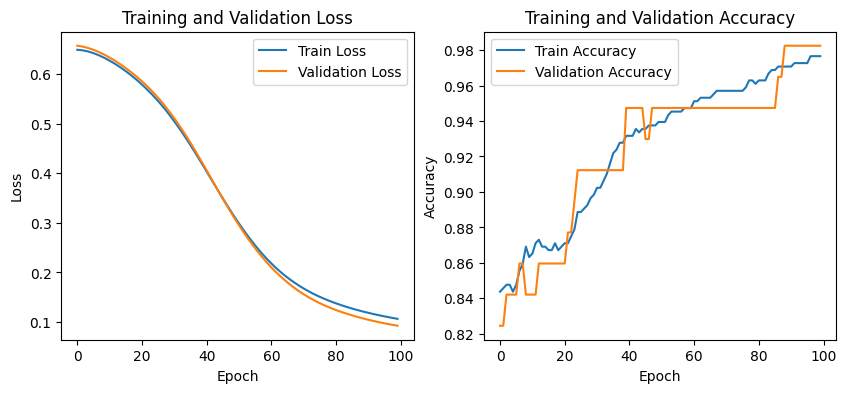

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plot_losses(plt, "Training and Validation Loss", train_losses, val_losses, label="Loss")
plt.subplot(1, 2, 2)
plot_losses(plt, "Training and Validation Accuracy", train_accuracy, val_accuracy, label="Accuracy")
plt.show()

In [ ]:
"""
Print final results
"""
# Calculate final validation accuracy
with torch.no_grad():
    y_val_hat = model(X_val)
    val_preds = (y_val_hat >= 0.5).float()
    val_correct = (val_preds == y_val).sum().item()
    val_accuracy = val_correct / y_val.size(0)  # fraction
    val_accuracy_percent = val_accuracy * 100  # convert to percentage

# Print results
print(f"Accuracy of the model on the validation data: {val_accuracy_percent:.2f}%")
print(f"Number of epochs to reach this accuracy: {epoch+1}")
print(f"Criterion used: {criterion}")

Accuracy of the model on the validation data: 98.25%
Number of epochs to reach this accuracy: 100
Criterion used: BCELoss()
